In [22]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')
%matplotlib inline

In [23]:
data = pd.read_csv("tqc_clean.csv")
data = data[['months', 'act0', 'act1', 'CPUE', 'biomass']]
data.head()

,months,act0,act1,CPUE,biomass
0,3,-0.911334,-0.843671,-1.0,-1.0
1,4,-0.964028,-0.703425,-1.0,-1.0
2,5,-0.964028,-0.904936,-1.0,-1.0
3,6,-0.884734,-0.851039,-1.0,-1.0
4,7,-0.839049,-0.761919,-1.0,-1.0


In [24]:
print(f"Data Information:\n")
data.info()
print("\n")

print(f"Data Statistics:\n")
data.describe()

Data Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49500 entries, 0 to 49499
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   months   49500 non-null  int64  
 1   act0     49500 non-null  float64
 2   act1     49500 non-null  float64
 3   CPUE     49500 non-null  float64
 4   biomass  49500 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 1.9 MB


Data Statistics:



,months,act0,act1,CPUE,biomass
count,49500.000000,49500.000000,49500.000000,49500.000000,49500.000000
mean,7.000000,-0.888111,-0.409029,-0.977542,-0.733758
std,2.582015,0.288826,0.484854,0.015604,0.110403
min,3.000000,-0.964028,-0.964028,-1.000000,-1.000000
25%,5.000000,-0.964028,-0.783104,-0.989823,-0.799352
50%,7.000000,-0.964028,-0.564876,-0.978055,-0.741966
75%,9.000000,-0.932135,-0.367526,-0.969455,-0.692060
max,11.000000,0.891763,0.964028,-0.878824,-0.005764


In [25]:
action_space = (-1, 1)
cpue_space = (-1, np.max(data['CPUE']))
biomass_space = (-1, np.max(data['biomass']))
num_bins = 4

def bin_map_creator(val, space, num_bins = None, bin_widths = None):
    if num_bins:
        bin_boundaries = np.linspace(space[0], space[1], num_bins + 1)
    else:
        bin_boundaries = np.array([])
        total = -1
        for width in bin_widths:
            bin_boundaries = np.append(bin_boundaries, total)
            total += width
        bin_boundaries = np.append(bin_boundaries, total)
    bins = np.array([(bin_boundaries[i], bin_boundaries[i+1]) for i in range(len(bin_boundaries) - 1)])
    
    for curr_bin in bins:
        left, right = curr_bin
        if left <= val < right:
            return curr_bin
    return bins[-1]

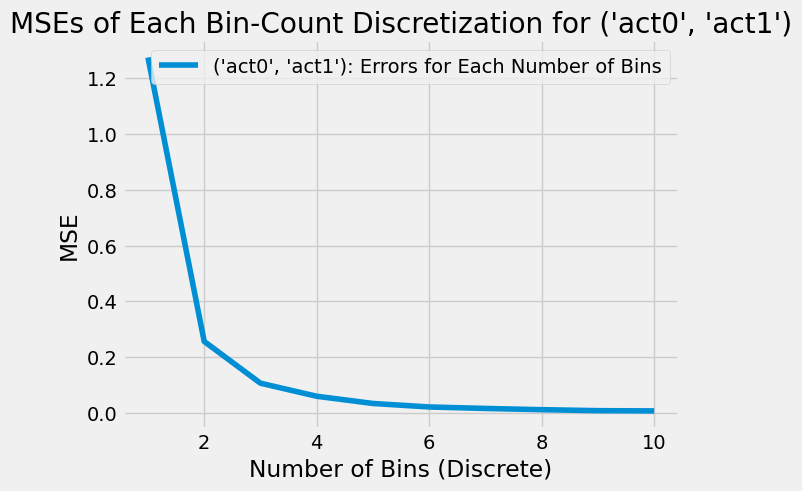

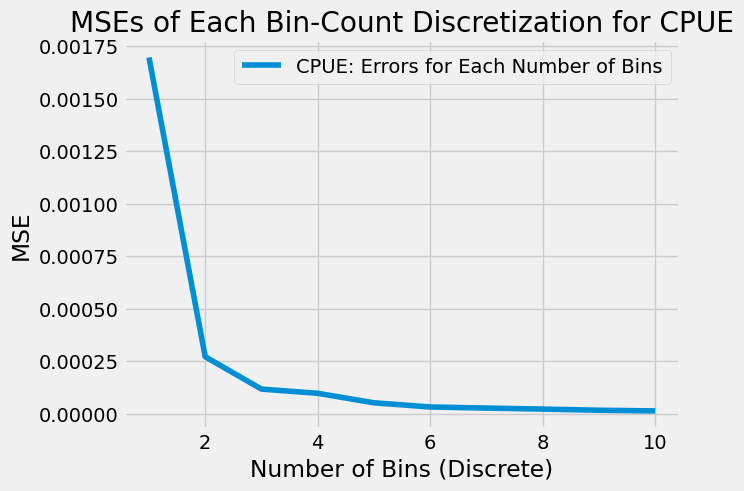

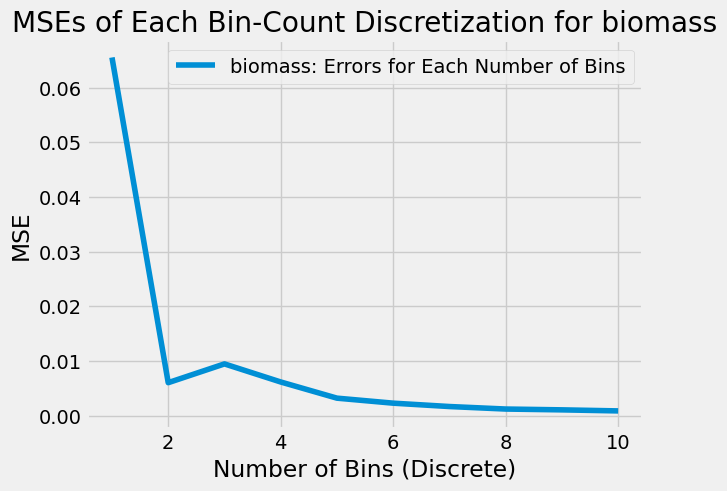

In [27]:
def objective_function(var, space, num_bins = None, bin_widths = None, month = None):
    curr_data = data[['months', 'act0', 'act1', 'CPUE', 'biomass']].copy()

    if month:
        curr_data = curr_data[curr_data['months'] == month]

    if num_bins:
        bin_mapper = lambda x: bin_map_creator(x, space, num_bins, None)
    else:
        bin_mapper = lambda x: bin_map_creator(x, space, None, bin_widths)

    bin_midpoint = lambda x: (x[1] + x[0]) / 2

    if isinstance(var, tuple):
        total_mse = 0
        for sub_var in var:
            curr_data[f'{sub_var}_bin'] = curr_data[sub_var].apply(bin_mapper)
            curr_data[f'{sub_var}_midpoint'] = curr_data[f'{sub_var}_bin'].apply(bin_midpoint)
            total_mse += mean_squared_error(curr_data[sub_var], curr_data[f'{sub_var}_midpoint'])
        return total_mse
    else:
        curr_data['bin'] = curr_data[var].apply(bin_mapper)
        curr_data['midpoint'] = curr_data['bin'].apply(bin_midpoint)
        return mean_squared_error(curr_data[var], curr_data['midpoint'])

spaces = [action_space, cpue_space, biomass_space]
bin_trials = np.arange(1, 11)
data_vars = [('act0', 'act1'), 'CPUE', 'biomass']
objective_trials_mses = []

for i in range(3):
    plt.figure(i + 1)
    var = data_vars[i]
    space = spaces[i]
    num_bin_objective_func = lambda x: objective_function(var, space, x, None)
    objective_trial_mses = np.array([num_bin_objective_func(num_bins) for num_bins in bin_trials])
    objective_trials_mses.append(objective_trial_mses)
    plt.plot(bin_trials, objective_trial_mses, label=f'{var}: Errors for Each Number of Bins')
    plt.xlabel('Number of Bins (Discrete)')
    plt.ylabel('MSE')
    plt.title(f'MSEs of Each Bin-Count Discretization for {var}')
    plt.legend()

In [28]:
def elbow_calculator(x, y):
    first_to_last_distance = np.sqrt((y[-1] - y[0]) ** 2 + (x[-1] - x[0]) ** 2)
    perpendicular_differences = list(np.abs((y[-1] - y[0]) * x - (x[-1] - x[0]) * y + x[-1] * y[0] - y[-1] * x[0]) / first_to_last_distance)
    return perpendicular_differences.index(max(perpendicular_differences)) + 1
    
for i in range(3):
    var, objective_trial_mses = data_vars[i], objective_trials_mses[i]
    print(f"Optimal Bin Count for {var} By Elbow: {elbow_calculator(bin_trials, objective_trial_mses)}")

Optimal Bin Count for ('act0', 'act1') By Elbow: 3
Optimal Bin Count for CPUE By Elbow: 2
Optimal Bin Count for biomass By Elbow: 2


In [44]:
optimal_width_data_all = {}
optimal_bin_trials = np.arange(2, 6)
month_dict = {3: "March", 4: "April", 5: "May", 6: "June", 7: "July", 8:"August", 9: "September", 10: "October", 11: "November"}
months = month_dict.keys()

def minimize_var_by_width(var, space, num_bins, month):
    width_objective_func = lambda x: objective_function(var, space, None, x, month)
    space_length = space[1] - space[0]
    width_constraints = {"type": "eq", "fun": lambda widths: np.sum(widths) - space_length}
    width_bounds = np.array([(1e-3, space_length) for i in np.arange(num_bins)])
    initial_guess = np.linspace(space[0], space[1], num_bins)
    optimal_width_data = minimize(width_objective_func, initial_guess, method='SLSQP', bounds=width_bounds, constraints=width_constraints)
    if var not in optimal_width_data_all.keys():
        optimal_width_data_all[(var, month)] = []
    optimal_width_data_all[(var, month)].append(optimal_width_data)
    print(f"Current Variable: {var}\nNumber of Bins: {num_bins}\nMonth: {month_dict[month]}\n{optimal_width_data}\n")

for num_bins in optimal_bin_trials:
    for month in months:
        for i in range(3):
            var = data_vars[i]
            space = spaces[i]
            minimize_var_by_width(var, space, num_bins, month)

Current Variable: ('act0', 'act1')
Number of Bins: 2
Month: March
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.1488040347719623
           x: [ 5.730e-01  1.427e+00]
         nit: 13
         jac: [-1.664e-01 -1.962e-01]
        nfev: 81
        njev: 13
 multipliers: [-2.072e-01]

Current Variable: CPUE
Number of Bins: 2
Month: March
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.00011099297845294715
           x: [ 4.304e-02  7.814e-02]
         nit: 4
         jac: [ 1.728e-11  0.000e+00]
        nfev: 12
        njev: 4
 multipliers: [-3.964e-27]

Current Variable: biomass
Number of Bins: 2
Month: March
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.002618874267988612
           x: [ 4.978e-01  4.964e-01]
         nit: 5
         jac: [ 7.181e-03  6.789e-03]
        nfev: 15
        njev: 5
 multipliers: [ 6.758e-03]


In [51]:
optimal_bins_all = {}

for i in range(3):
    for month in months:
        var = data_vars[i]
        space = spaces[i]
        space_length = space[1] - space[0]
        
        optimal_width_data = optimal_width_data_all[(var, month)]
        min_error_widths = min(optimal_width_data, key=lambda x: x.fun).x
        optimal_widths = np.round(min_error_widths, 3)
        
        optimal_bin_boundaries = np.array([])
        total = space[0]
        for width in optimal_widths:
            optimal_bin_boundaries = np.append(optimal_bin_boundaries, total)
            total += width
        optimal_bin_boundaries = np.append(optimal_bin_boundaries, total)
        
        optimal_bins = np.array([(optimal_bin_boundaries[i], optimal_bin_boundaries[i+1]) for i in range(len(optimal_bin_boundaries) - 1)])
        optimal_bins_all[(var, month)] = optimal_bins
        print(f"Optimal Bins for {var} in {month_dict[month]}:\n{optimal_bins}\n")

Optimal Bins for ('act0', 'act1') in March:
[[-1.    -0.947]
 [-0.947 -0.895]
 [-0.895 -0.843]
 [-0.843 -0.041]
 [-0.041  1.   ]]

Optimal Bins for ('act0', 'act1') in April:
[[-1.    -0.999]
 [-0.999 -0.998]
 [-0.998 -0.997]
 [-0.997 -0.404]
 [-0.404  1.   ]]

Optimal Bins for ('act0', 'act1') in May:
[[-1.    -0.996]
 [-0.996 -0.992]
 [-0.992 -0.988]
 [-0.988 -0.564]
 [-0.564  1.001]]

Optimal Bins for ('act0', 'act1') in June:
[[-1.    -0.999]
 [-0.999 -0.998]
 [-0.998 -0.997]
 [-0.997 -0.483]
 [-0.483  1.   ]]

Optimal Bins for ('act0', 'act1') in July:
[[-1.    -0.976]
 [-0.976 -0.952]
 [-0.952 -0.928]
 [-0.928 -0.227]
 [-0.227  0.999]]

Optimal Bins for ('act0', 'act1') in August:
[[-1.    -0.997]
 [-0.997 -0.994]
 [-0.994 -0.991]
 [-0.991 -0.529]
 [-0.529  1.001]]

Optimal Bins for ('act0', 'act1') in September:
[[-1.    -0.974]
 [-0.974 -0.956]
 [-0.956 -0.939]
 [-0.939 -0.307]
 [-0.307  1.   ]]

Optimal Bins for ('act0', 'act1') in October:
[[-1.    -0.999]
 [-0.999 -0.998]
 [

In [53]:
import json

optimal_bins_serializable = {
    f"{var}_{month}": bounds.tolist()
    for (var, month), bounds in optimal_bins_all.items()
}

with open("optimal_bins.json", "w") as f:
    json.dump(optimal_bins_serializable, f)